### Zyxin segmentation and object feature analysis

with Patrick's 2D fixed image two types of Zyxin

Liya Ding, 2025.4

In [1]:
import os
import sys
import tifffile 
import czifile
import numpy as np
import pandas as pd

In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.FA_object_segmentation import FA_obj_segmenter
from core.FA_obj_feature_extraction import FA_obj_feature_extractor
from utils.display_utils import display_fa_segmentation_panels

In [3]:
ctrl_y_str = 'ctrl'
major_fa_ch = 3
method_ID = 'code_org_20250902'


In [4]:
front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [5]:
if ctrl_y_str == 'ctrl':
    image_2D_4CH_dir =  '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Control'
else:
    image_2D_4CH_dir =  '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'
    
output_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str + '_ch' + str(major_fa_ch) + '_major'

all_channels = [0, 1, 2]

# Compute supplementary channels
supplementary_fa_ch = [ch for ch in all_channels if ch != major_fa_ch]

cellmask_ch = 3
os.makedirs(output_dir, exist_ok=True)


csv_output_dir = os.path.join(output_dir, method_ID+'_csv')
plot_output_dir = os.path.join(output_dir, method_ID+'_plot')
seg_output_dir = os.path.join(output_dir, method_ID+'_seg')

pixel_size = 0.13
time_point = 0

os.makedirs(csv_output_dir, exist_ok=True)
os.makedirs(plot_output_dir, exist_ok=True)
os.makedirs(seg_output_dir, exist_ok=True)

sub_dirs = ['mask', 'seg', 'label', 'togglelabel', 'rgb']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(seg_output_dir, sub_dir), exist_ok=True)


### for each 3D stack run through MIP and 8th frame

In [6]:
# flag for some optinal parts
flag_plot = True
flag_plot_save = True
flag_seg_save = True
flag_csv_save = True
flag_panel_plot = True
flag_run_all  = True

In [7]:
# select the cells that are single/disconnected and complete
ctrl_one_cell_list = [0,1,2,3,4,5,6,7,8,9]

In [8]:
# Get list of .czi files
filenames = [x for x in os.listdir(image_2D_4CH_dir)
             if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and x.endswith('.czi')]


# Read all image data and collect flattened intensities per channel
for filename in filenames:
    print(filename)
    input_multich_img = np.squeeze(czifile.imread(os.path.join(image_2D_4CH_dir, filename)))

    for ch_id in range(input_multich_img.shape[0]):
        ch_img = input_multich_img[ch_id, :, :]
        if(ch_id==1):
            print([int(np.mean(ch_img.flatten())), int(np.std(ch_img.flatten()))])
        

eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-01.czi
[2527, 5037]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-02.czi
[2164, 4226]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-03.czi
[2358, 5282]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-04.czi
[3562, 5891]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-05.czi
[1657, 3959]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-06.czi
[2094, 4098]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-07.czi
[4093, 8546]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-08.czi
[6160, 12618]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-09.czi
[3906, 8676]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-10.czi
[3314, 6935]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-11.czi
[1448, 2754]
eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m

In [ ]:
if 0:#os.path.exists(os.path.join(image_2D_4CH_dir,"channel_profiles.csv")):
    profile_df = pd.read_csv(os.path.join(image_2D_4CH_dir,"channel_profiles.csv"))
    master_profile = profile_df.iloc[0].to_dict()
else:
    # Get list of .czi files
    filenames = [x for x in os.listdir(image_2D_4CH_dir)
                if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and x.endswith('.czi')]

    # This will store per-channel intensities across all images
    per_ch_all_intensities = []

    # Read all image data and collect flattened intensities per channel
    for filename in filenames:
        input_multich_img = np.squeeze(czifile.imread(os.path.join(image_2D_4CH_dir, filename)))

        if not per_ch_all_intensities:
            per_ch_all_intensities = [[] for _ in range(input_multich_img.shape[0])]

        for ch_id in range(input_multich_img.shape[0]):
            ch_img = input_multich_img[ch_id, :, :]
            per_ch_all_intensities[ch_id].append(ch_img.flatten())

    # Combine profiles for all channels
    master_profile = {}

    percentiles = [0, 0.1, 0.2, 0.5, 1, 2,5,25, 50, 75,95,98, 99, 99.5, 99.8, 99.9, 100]

    for ch_id, flattened_list in enumerate(per_ch_all_intensities):
        # Convert to 2D array and flatten to a single vector
        all_pixels = np.concatenate(flattened_list, axis=0)

        master_profile[f'ch{ch_id}_mean'] = float(np.mean(all_pixels))
        master_profile[f'ch{ch_id}_std'] = float(np.std(all_pixels))

        for p in percentiles:
            master_profile[f'ch{ch_id}_percentile_{p}'] = float(np.percentile(all_pixels, p))

    # Convert to DataFrame and save or print
    profile_df = pd.DataFrame([master_profile])

    # Optional: save to CSV
    profile_df.to_csv(os.path.join(image_2D_4CH_dir,"new_channel_profiles.csv"), index=False)


In [21]:
major_fa_ch

3

In [22]:
import matplotlib.pyplot as plt
# for all tif files 
filenames = [x for x in os.listdir(image_2D_4CH_dir) if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and ('.czi' in x)]

# # if not in run all mode, only test with the first image of the first movie
# if not flag_run_all:
#     filenames = filenames[:2]

for filenameID in range(0,len(filenames)):
# for filenameID in range(0,15):
    
    filename = filenames[filenameID]

    number = int(filename[-6:-4])
    # if number not in ctrl_one_cell_list:
    #     continue

    input_multich_img = np.squeeze(czifile.imread(os.path.join(image_2D_4CH_dir,filename)))
    # input_multich_img = np.transpose(input_multich_img, (2, 0, 1))

    # Initialize the segmenter
    segmenter = FA_obj_segmenter(cellmask_ch = cellmask_ch, major_fa_ch = major_fa_ch, thres_cellmask = 1400,  
                                    intensity_scaling_param = (0.5, 5), 
                                    sauvola_window_size = 601,
                                    sauvola_k = -20,
                                    response_threshold = 0.09, major_FA_res_thresholds = [0.7, 0.8, 0.9], min_object_size= 15, intensity_profile = master_profile )

    # Perform segmentation
    [major_FA_seg, new_cell_mask] = segmenter.apply_fa_obj_segmentation(input_multich_img)

    pax_img = input_multich_img[1,:,:]

    intensity_incell = pax_img[new_cell_mask>0]
    vmin = np.percentile(intensity_incell,0.2)
    vmax = np.percentile(intensity_incell,99.8)

    pax_img_norm = (pax_img-vmin)/(vmax-vmin)

    

    # fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=128, facecolor='w', edgecolor='k')
    # plt.imshow(pax_img_norm,vmin=0,vmax=1,cmap='gray')
    
   
   


In [23]:
# for all tif files 
filenames = [x for x in os.listdir(image_2D_4CH_dir) if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and ('.czi' in x)]

# # if not in run all mode, only test with the first image of the first movie
# if not flag_run_all:
#     filenames = filenames[:2]

for filenameID in range(0,len(filenames)):
# for filenameID in range(0,1):
    
    filename = filenames[filenameID]

    number = int(filename[-6:-4])
    # if number not in ctrl_one_cell_list:
    #     continue

    input_multich_img = np.squeeze(czifile.imread(os.path.join(image_2D_4CH_dir,filename)))
    # input_multich_img = np.transpose(input_multich_img, (2, 0, 1))


    # Initialize the segmenter
    segmenter = FA_obj_segmenter(cellmask_ch = cellmask_ch, major_fa_ch = major_fa_ch, thres_cellmask = 1400,  
                                    intensity_scaling_param = (0.5, 5), 
                                    sauvola_window_size = 1501,
                                    sauvola_k = -2,
                                    response_threshold = 0.05, major_FA_res_thresholds = [0.5, 0.6, 0.65], min_object_size= 15, intensity_profile = master_profile )

    # Perform segmentation
    [major_FA_seg, new_cell_mask] = segmenter.apply_fa_obj_segmentation(input_multich_img)
   
    if os.path.isfile(os.path.join(front_mask_dir,'frontmask-'+filename[:-4]+'.tif')):
        front_mask = tifffile.imread(os.path.join(front_mask_dir,'frontmask-'+filename[:-4]+'.tif'))
    else:
        print('frontmask-'+filename[:-4]+'.tif mask file not found')
        front_mask = new_cell_mask

    label_filename = os.path.join(os.path.join(seg_output_dir, 'label'), 'FA_obj_label_'+filename+'.tif')
    from skimage.measure import label, regionprops
    label_seg_img = label(major_FA_seg)
    tifffile.imsave(label_filename, label_seg_img.astype(np.uint16))       
    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'mask'), 'cell_mask_'+filename+'.tif'),new_cell_mask.astype(np.uint8))   
    

    # Extract Object features
    extractor = FA_obj_feature_extractor(filename = filename,  label_filename =label_filename,  pax_seg = major_FA_seg, input_multich_img = input_multich_img,
                                                        new_cell_mask = new_cell_mask, front_mask = front_mask, major_fa_ch = major_fa_ch,
                                                        filenameID = filenameID,supplementary_fa_ch=supplementary_fa_ch, intensity_profile = master_profile)

    [fa_obj_features, local_orientation] = extractor.extract_features()
    

    fa_obj_features.to_csv(os.path.join((csv_output_dir), 'fa_obj_features_'+filename+'.csv'))


    # Plot figures for debug and presentation
    pax_image_label_overlay = display_fa_segmentation_panels(input_image = (input_multich_img[major_fa_ch,:,:]), 
                                                             input_cell_mask = new_cell_mask, input_front_mask=front_mask/255,
                                                            input_obj_seg = major_FA_seg, local_orientation = local_orientation,
                                   plot_output_dir = plot_output_dir, filename = filename, flag_plot_save = flag_plot_save, flag_run_all = flag_run_all, intensity_profile = master_profile,
                                    intensity_scaling_param = [2,10],    major_fa_ch = major_fa_ch)

    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'rgb'), 'pax_segrgb_'+filename+'.jpg'),pax_image_label_overlay)                     
       

3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]
3
[0, 1, 2]


In [24]:
from scipy.ndimage import distance_transform_cdt
iL=3
label_pax_seg = label(major_FA_seg)
this_obj_bw = label_pax_seg == iL
not_this_obj_bw = (major_FA_seg > 0) & (label_pax_seg != iL)
distance_this_obj_bw = distance_transform_cdt( 1-this_obj_bw, metric="taxicab")
min_obj_distance = min(distance_this_obj_bw[not_this_obj_bw>0])

In [25]:
from skimage.filters import rank
from skimage.morphology import binary_opening, binary_dilation, disk
density_d15_map = rank.mean((major_FA_seg>0).astype(np.uint8)*255, disk(9))
        

In [26]:
fa_obj_features.columns

Index(['filename', 'label_filename', 'cell_ID', 'time_point', 'pixel_size',
       'area', 'bbox_area', 'convex_area', 'eccentricity',
       'equivalent_diameter', 'euler_number', 'extent', 'filled_area', 'label',
       'major_axis_length', 'max_intensity', 'mean_intensity', 'min_intensity',
       'minor_axis_length', 'orientation', 'perimeter', 'solidity',
       'cell_edge_dist', 'cell_edge_orient', 'diff_orient', 'pax_raw_int_mean',
       'pax_group_norm_int_mean', 'pax_indiv_norm_int_mean',
       'sup1_raw_int_mean', 'sup1_group_norm_int_mean',
       'sup1_indiv_norm_int_mean', 'sup2_raw_int_mean',
       'sup2_group_norm_int_mean', 'sup2_indiv_norm_int_mean',
       'min_obj_distance', 'density_d25_this_obj', 'density_d9_this_obj',
       'density_d15_this_obj'],
      dtype='object')

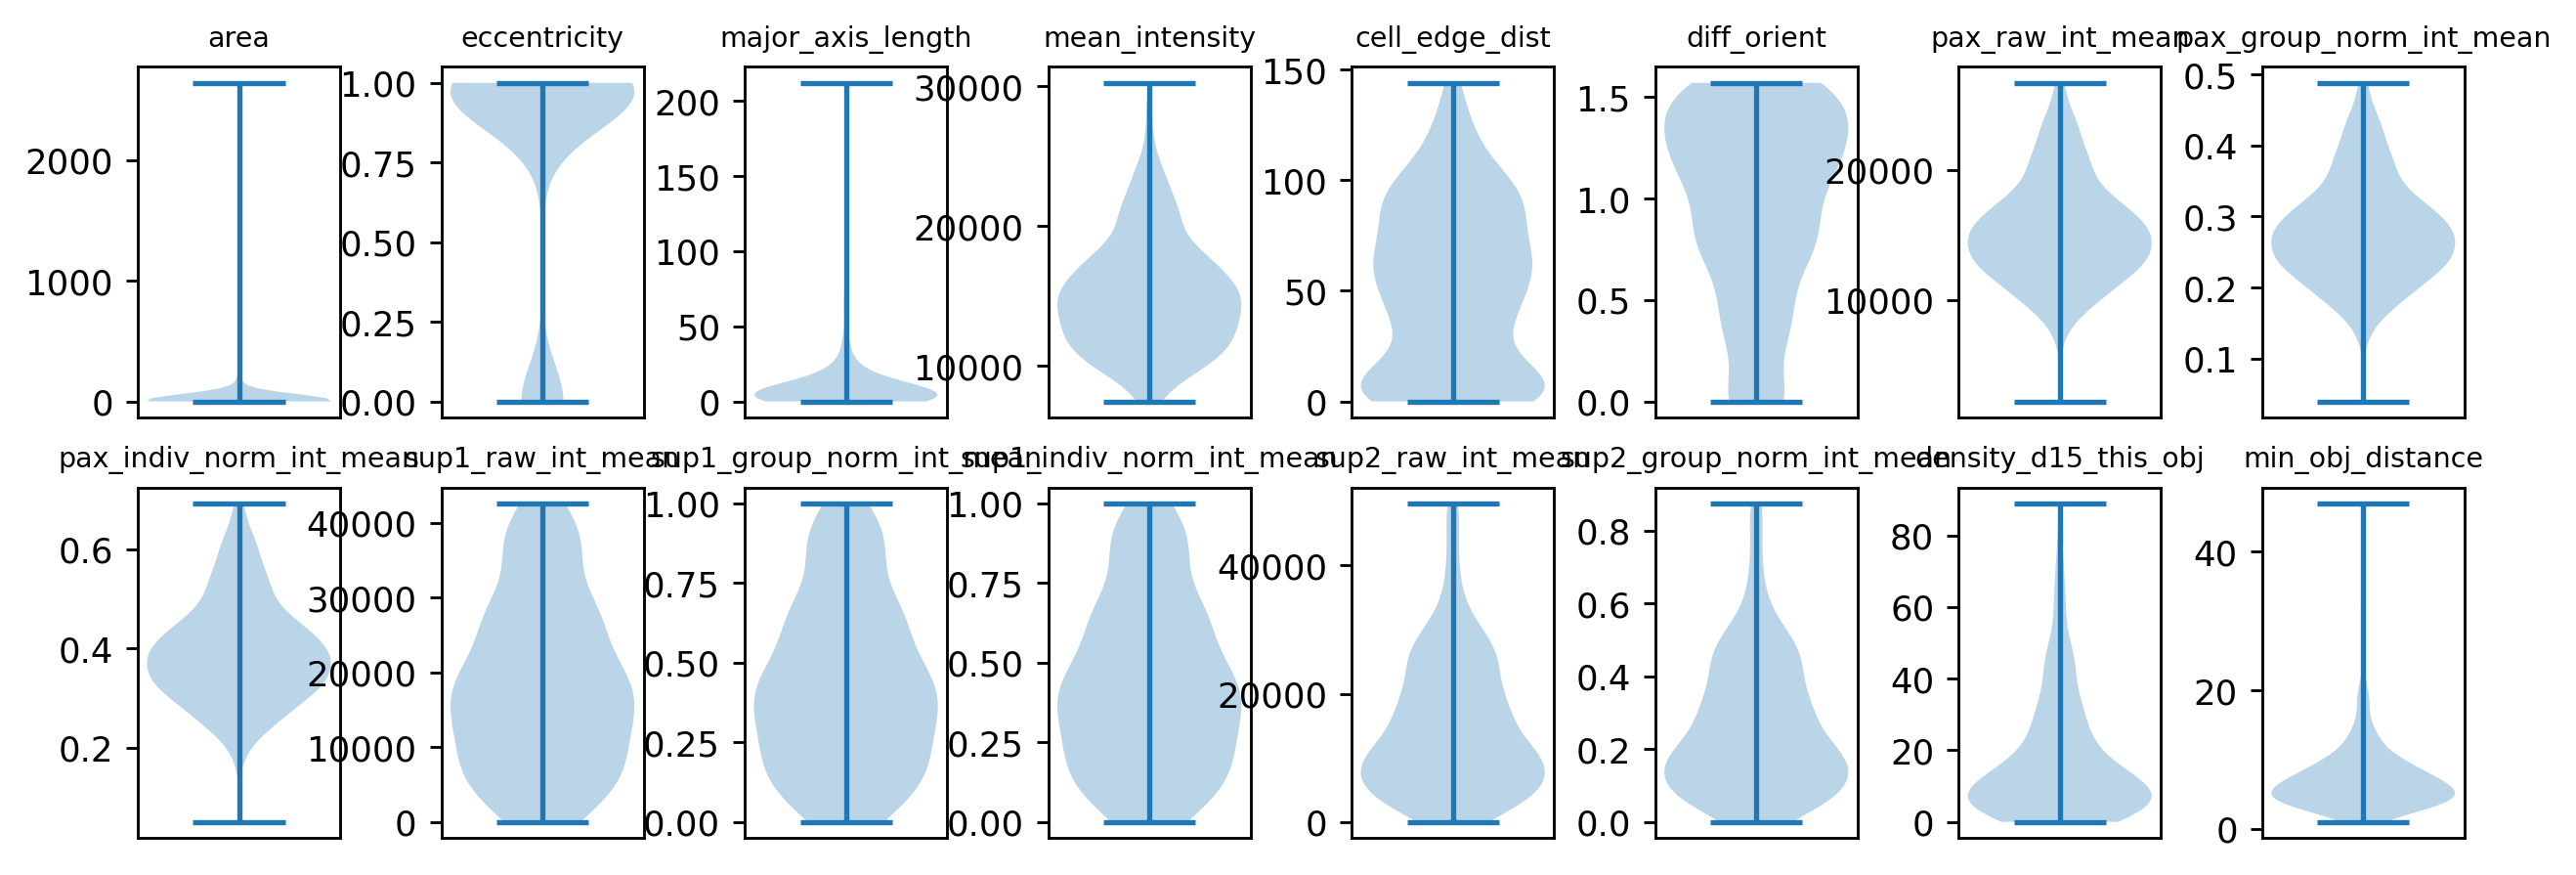

In [27]:
import matplotlib.pyplot as plt 
feature_list = ['area', 'eccentricity', 'major_axis_length','mean_intensity',
                                  'cell_edge_dist','diff_orient','pax_raw_int_mean',
       'pax_group_norm_int_mean', 'pax_indiv_norm_int_mean',
       'sup1_raw_int_mean', 'sup1_group_norm_int_mean',
       'sup1_indiv_norm_int_mean', 'sup2_raw_int_mean',
       'sup2_group_norm_int_mean', 'density_d15_this_obj','min_obj_distance']

fig, ax = plt.subplots(2, 8, figsize=(12,4), dpi=256, facecolor='w', edgecolor='k')
# plt.subplots_adjust(left=0.3, right=0.7, top=0.8, bottom=0.2)
col_ind = 0
row_ind = 0
import seaborn as sns


for feature in feature_list:
    # sns.violinplot([prop_df_pfak_all[feature][::10].to_numpy().flat],split=True, inner="quart",color='lightblue',ax=ax[row_ind, col_ind])
    V = fa_obj_features[feature].to_numpy().flat
    ax[row_ind, col_ind].violinplot(V)
    ax[row_ind, col_ind].set_title(feature,fontsize=8)
    ax[row_ind, col_ind].set_xticks([],fontsize=8)
    # ax[row_ind, col_ind].set_yticks([np.percentile(V,0.0), int(np.percentile(V,0.0)*2+np.percentile(V,100.0)*1)/3, int(np.percentile(V,0.0)*1+np.percentile(V,100.0)*2)/3,np.percentile(V,100)],fontsize=5)
    # ax[row_ind, col_ind].set_ylim([np.percentile(V,0.0),np.percentile(V,100)])
    ax[row_ind, col_ind].tick_params(axis='both', which='minor', labelsize=8)    
    
    col_ind = col_ind + 1

    if(col_ind==8):
        col_ind = 0
        row_ind = 1
fig.subplots_adjust(wspace=0.5)

In [28]:
fa_obj_features

,filename,label_filename,cell_ID,time_point,pixel_size,area,bbox_area,convex_area,eccentricity,equivalent_diameter,...,sup1_raw_int_mean,sup1_group_norm_int_mean,sup1_indiv_norm_int_mean,sup2_raw_int_mean,sup2_group_norm_int_mean,sup2_indiv_norm_int_mean,min_obj_distance,density_d25_this_obj,density_d9_this_obj,density_d15_this_obj
0,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,1.0,1.0,1.0,0.000000,1.128379,...,3472.169964,0.081470,0.081470,3460.841758,0.060958,0.060828,1.0,1.0,1.0,0.0
1,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,7.0,10.0,8.0,0.961409,2.985411,...,13292.000000,0.311880,0.311880,11090.000000,0.195335,0.195222,21.0,4.0,8.0,6.0
2,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,22.0,63.0,27.0,0.965061,5.292567,...,10530.000000,0.247073,0.247073,6153.142857,0.108379,0.108254,9.0,4.0,24.0,9.0
3,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,3.0,4.0,3.0,0.816497,1.954410,...,1147.863636,0.026933,0.026933,1565.500000,0.027574,0.027437,6.0,4.0,19.0,11.0
4,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,16.0,90.0,30.0,0.984802,4.513517,...,325.333333,0.007634,0.007634,3261.333333,0.057444,0.057311,6.0,8.0,16.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,10.0,15.0,12.0,0.885316,3.568248,...,17669.495327,0.414592,0.414592,13663.747664,0.240667,0.240562,4.0,1.0,10.0,5.0
320,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,3.0,3.0,3.0,1.000000,1.954410,...,22251.900000,0.522112,0.522112,4962.500000,0.087407,0.087279,12.0,43.0,16.0,33.0
321,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,291.0,3230.0,485.0,0.999133,19.248707,...,16553.666667,0.388410,0.388410,15888.000000,0.279844,0.279745,8.0,22.0,55.0,33.0
322,eGFPZyxin488_Phalloidin405_Vinculin(rb)647_pax...,/mnt/d/lding/FA/analysis_results/FA_ML_Annabel...,49.0,0.0,0.07,2.0,2.0,2.0,1.000000,1.595769,...,28165.831615,0.660875,0.660875,22923.515464,0.403765,0.403684,4.0,24.0,11.0,30.0
